# PSY 39200 Introduction to Computational Psychology and AI

## Week 11 Boltzmann Machine

## There are 3 sets of questions and 3 coding exercises in this tutorial

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University


# **Please enable GPU in this notebook**  

In [1]:
# @title Set Up Code

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Set a fixed seed value
SEED = 0

# Fix seed for NumPy (used in Hopfield network updates)
np.random.seed(SEED)


# Helper functions

def create_random_patterns(n_neurons, p):
    """
    Generate p random patterns of length n_neurons.
    Each entry is +1 or -1 with probability 1/2.
    """
    return [np.random.choice([+1, -1], size=n_neurons) for _ in range(p)]

def flip_bits(pattern, n_flip=5):
    """
    Create a noisy version of 'pattern' by flipping n_flip random bits.
    """
    noisy = pattern.copy()
    flip_indices = np.random.choice(range(len(pattern)), size=n_flip, replace=False)
    noisy[flip_indices] *= -1
    return noisy

def overlap(x, y):
    """
    Compute the overlap between two patterns (in {+1, -1}).
    Overlap = (1/N) * sum_i x_i * y_i
    Range is [-1, 1]. 1 means identical patterns, -1 means opposite.
    """
    return np.mean(x * y)

import numpy as np
import matplotlib.pyplot as plt



# Function to create 10x10 letter patterns
def generate_letter_patterns():
    letters = {
        "A": [
            "0011111000",
            "0100000100",
            "0100000100",
            "0100000100",
            "0111111100",
            "0100000100",
            "0100000100",
            "0100000100",
            "0100000100",
            "0000000000"
        ],
        "B": [
            "0111111000",
            "0100000100",
            "0100000100",
            "0100000100",
            "0111111000",
            "0100000100",
            "0100000100",
            "0100000100",
            "0111111000",
            "0000000000"
        ],
        "C": [
            "0011111000",
            "0100000100",
            "0100000000",
            "0100000000",
            "0100000000",
            "0100000000",
            "0100000000",
            "0100000100",
            "0011111000",
            "0000000000"
        ],
        "D": [
            "0111110000",
            "0100001000",
            "0100000100",
            "0100000100",
            "0100000100",
            "0100000100",
            "0100000100",
            "0100001000",
            "0111110000",
            "0000000000"
        ],
        "E": [
            "0111111100",
            "0100000000",
            "0100000000",
            "0100000000",
            "0111111000",
            "0100000000",
            "0100000000",
            "0100000000",
            "0111111100",
            "0000000000"
        ]
    }

    patterns = []
    for letter, matrix in letters.items():
        binary_pattern = np.array([[1 if c == '1' else -1 for c in row] for row in matrix])
        binary_pattern = binary_pattern.astype(np.float32).flatten()  # Force float32
        patterns.append(binary_pattern)

    return patterns

# Function to display a pattern

def plot_pattern(pattern, title):
    plt.imshow(pattern.reshape(10, 10), cmap="gray_r")
    plt.title(title)
    plt.axis("off")
    plt.show()

def plot_three_patterns(original_pattern, noisy_pattern, recalled_pattern):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns

    # Titles for each plot
    titles = ["Original Pattern", "Retrieval Cue", "Recalled Pattern"]
    patterns = [original_pattern, noisy_pattern, recalled_pattern]

    # Loop through the three plots
    for i, ax in enumerate(axes):
        ax.imshow(patterns[i].reshape(10, 10), cmap="gray_r")
        ax.set_title(titles[i])
        ax.axis("off")  # Remove axes for better visualization

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()




# Boltzmann Machine

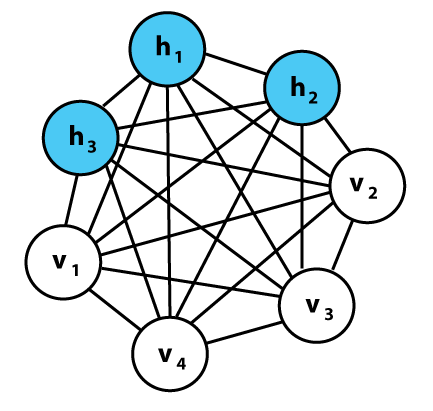

Source: https://en.wikipedia.org/wiki/Boltzmann_machine#/media/File:Boltzmannexamplev1.png

## From Hopfield Networks to Boltzmann Machines

The **Hopfield network** and the **Boltzmann machine** are closely related models in neural computation and statistical physics. One way to view the Boltzmann machine is as a **stochastic, general-purpose extension** of the Hopfield model, allowing for richer dynamics and learning rules based on thermodynamic principles.

---

## 1. Hopfield Network Recap

1. **Binary Neurons**: Each neuron $s_i \in \{+1, -1\}$ (or sometimes $\{0, 1\}$).  
2. **Symmetric Weights**: $ w_{ij} = w_{ji} $.  
3. **Energy Function** (a Lyapunov function):  
   $$
     E(\mathbf{s})
     \;=\; -\frac{1}{2}\sum_{i \neq j} w_{ij}\, s_i \, s_j \;-\;\sum_i \theta_i\, s_i.
   $$
4. **Deterministic Updates**: Asynchronously flip one neuron at a time according to the weight updating rule to lower the total energy.  

In a Hopfield network, **stable states** (local minima of $E$) act as **stored memories** or **attractors**.

---

## 2. Generalizing Hopfield to Boltzmann Machines

### 2.1. Introducing Stochasticity by Introducing a Parameter Temperature

1. **Stochastic Dynamics**:  
   Instead of a purely deterministic rule “flip the neuron according to the weight updating rule to lower the energy,” each neuron **stochastically** flips with a probability described by the sigmoid function governed by a Boltzmann factor:

   $$
     P(x_i \leftarrow \text{flip})
     \;=\;
     \sigma\bigl(\beta\,(\Delta E)\bigr) = \frac{1}{1+exp(-\beta \Delta E)}  
   $$

   (or something similar), where $\Delta E$ is the energy change upon flipping neuron $i$, and $\beta = 1/(k_B T)$ acts as an inverse temperature. $k_B$ is Boltzmann constant, it is not important and can be ignored in the model.

2. **Temperature**

   The parameter $ T $ is the temperature of the neural network model. It is not the thermal temperature that we know in our daily life. It is a parameter defined for describing the overall level of activities of a neural network. Similar to the absolute temperature in thermal physics, the temperature in Boltzmann machine is almost always nonnegative.

   - At higher temperatures, neuron state flips are more random and energy of the neural network could go up or down.

   - At low temperatures, neuron state flips are more deterministic and the neural network system mostly only prefers to move downhill in energy.

   - For Boltzmann machine, the temperatue is usually set to a fixed value such that $\beta = 1/(k_B T) = 1$    


3. **Boltzmann Distribution**:  
   With these stochastic updates, the system follows a **probability distribution** over a state vector $\mathbf{s}$ given by the **Boltzmann distribution**:

   $$
     P(\mathbf{s})
     \;=\; \frac{1}{Z} \exp\bigl(-\beta\,E(\mathbf{s})\bigr)
   $$

   Where $Z = \sum_{all\;possible\;\mathbf{s'}} \exp\bigl(-\beta\,E(\mathbf{s'})\bigr)$ is called the partition function.

   This ensures that, at thermal equilibrium, the probability distribution is stationary and each state's probability is proportional to $e^{-\beta E(\mathbf{x})}$, linking the network to statistical physics.

### 2.2. Hidden Units and Learning a Distribution

- All neurons in a **Hopfield network** are visible neurons, with the possibility of storing certain patterns as stable states.  
- The **Boltzmann machine** extends this concept to allow for **hidden neurons** that are never clamped to data, providing much more expressive power for representing complex distributions.  
- By combining visible and hidden neurons, the Boltzmann machine can learn to model the **joint probability distribution** of the visible variables.




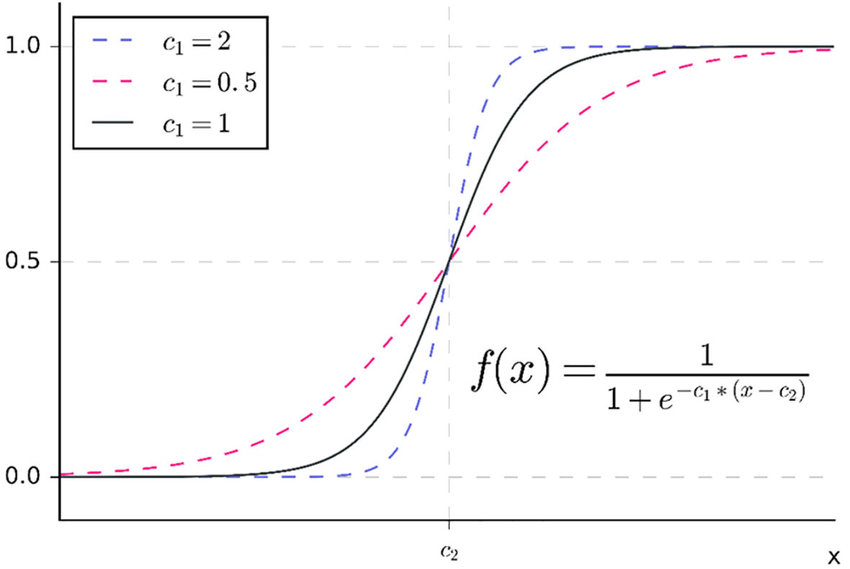

Temperature affects the shape of the sigmoid function.

Source: https://www.researchgate.net/figure/Basic-sigmoid-function-Note-A-Basic-sigmoid-function-with-two-parameters-c-1-and-c-2_fig2_327512672

# Question #1

In the plot shown above, which curve corresponds to the sigmoid function in Boltzmann machine with the highest temperature? Which curve corresponds to the sigmoid function with the lowest temperature?

Highest Temperature: c1 = 0.5

Lowest Temperature: c1 = 2

## Boltzmann Machine Theory

### 1. Structure: Visible and Hidden Units

A **Boltzmann machine** (BM) is a network of binary $\{\pm1\}$ or $\{0,1\}$ units, typically split into:
- **Visible units**: Represent the variables we observe or data we clamp.  
- **Hidden units**: Additional, unobserved variables that help the machine capture more complicated dependencies among visible variables.

During training, all visible units are clamped to the input training data and their states cannot be changed after being clamped. All hidden units can change their states.

After training and when using Boltzmann machine to reconstruct data, both visible units and hidden units can change their states.

A general Boltzmann machine can be **fully connected** (all units connected to all others), or partially connected (some structure of edges only). Typically:
- **Weights are symmetric**: $ w_{ij} = w_{ji} $.  
- **Biases**: $ \theta_i $ for each unit $i$.  

### 2. Energy Function

The energy of a state $\mathbf{s}$ in a Boltzmann machine is:

$$
E(\mathbf{s})
\;=\;
-\frac{1}{2} \sum_{i\neq j} w_{ij}\, s_i\, s_j
\;-\;\sum_i \theta_i\, s_i,
$$


where $\mathbf{s}$ includes both visible and hidden units.

- $\mathbf{s} = (\mathbf{v}, \mathbf{h})$, combining visible neurons $\mathbf{v}$ and hidden neurons $\mathbf{h}$.










### 3. The Concept of Ensemble in Statistical Physics and Boltzmann Machine

#### **3.1 Ensemble in Statistical Physics**

An ensemble in statistical physics is a probability distribution over all possible microstates of a system, subject to specified constraints (e.g., fixed energy, temperature, or particle number).

Instead of tracking the exact state of every individual particle (typically impossible) we use an ensemble to describe the system statistically, assigning probabilities to different possible states of the entire system.  

We will be focusing on the **Microcanonical Ensemble** and the **Canonical Ensemble** when discussing the Boltzmann machine.

##### **Types of Ensembles in Statistical Physics**

| **Ensemble Type** | **Key Properties** | **Fixed Quantities** |
|------------------|------------------|----------------|
| **Microcanonical Ensemble** | Isolated system, no exchange of energy or particles | Volume $V$, Energy $E$, Number of Particles $N$ |
| **Canonical Ensemble** | System in thermal equilibrium with a heat bath (exchange energy), but no exchange of particles | Volume $V$, Temperature $T$, Number of Particles $N$ |
| **Grand Canonical Ensemble** | System exchanges both energy and particles with a reservoir |  Volume $V$, Temperature $T$, Chemical Potential $ \mu $ |



##### **3.1.1 Microcanonical Ensemble (Uniform Distribution)**

- **Real-World Example**: Distribution of the different possible states $s$ (different positions and momenta) of a cup of coffee when the total energy of the molecules in the coffee $E$ is fixed.

From the postulates of statistical mechanics that all microstates are equally probable, the probability of the coffee being in any microstate is:

$$
P(s) = \frac{1}{\Omega(E)}
$$

Where $\Omega(E)$ is the total number of possible states $s$ of the coffee given the constraint that the total energy of the coffee is $E$.


##### **3.1.2 Canonical Ensemble (Boltzmann Distribution)**

- **Real-World Example**: Distribution of energy of a cup of coffee when the coffee has reached thermal equilibrium by exchanging heat with the environment at a constant temperature $T$.

A canonical ensemble describes the distribution of the microstates of the molecules in the coffee at thermal equilibrium. The total energy is not fixed but fluctuates, and its distribution is induced by the distribution over microstates.

The coffee molecules exchange energy with the environment. The entire cup is in thermal equilibrium with the room at a constant temperature $T$. Therefore, the average total energy is a constant, but the total energy of the coffee at different time fluctuates when the molecules in the coffee are transitioning between different microstates.

The microstates distribution is following the probability distribution:  

$$
P(s) = \frac{e^{-E_s / (k_B T)}}{Z}
$$

where:
- $ k_B $ is **Boltzmann's constant**.
- $ T $ is the **temperature**.
- $ Z = \sum_{all\;possible\;s'} e^{-E_s / k_B T}$ is the **partition function**, which normalizes the probabilities.

This probability distribution is called the **Boltzmann Distribution**.

The microstates of the coffee follows this distribution because it is the **maximum entropy distribution** when the only constraints in the system are that **the average energy of the system is fixed** and the normalization of probability.

---

#### **2. Ensemble in Boltzmann Machines**

In **Boltzmann Machines**, an **ensemble** represents the **set of all possible states** of a neural network, each with a probability determined by an energy function.

In other words, the whole neural network is like a cup of coffee.

The energy of the neural network is determined by all the weights and neural activity states in the network using the energy function defined above.

If two states of a Boltzmann machine have the same energy, then they are in the same microcanonical ensemble and they have the same probability.

However, in general, different states of a Boltzmann machine have different energies and the average energy is a constant when it has reached **thermal equilibrium**, so the states distribution can be described using a **canonical ensemble**.

##### **Boltzmann Distribution in Boltzmann Machines**

The energy is not fixed because the state of a Boltzmann machine is always fluctuating across time. However, the **Boltzmann machine is assumed to reach thermal equilibrium during each weight updating step** when we are training it, so **the average energy of a Boltzmann machine is fixed**.

Therefore, according to the **maximum entropy principle** derived using canonical ensemble, the probability distribution of the state of a Boltzmann machine at any given time should also follow the **Boltzmann distribution**.

A Boltzmann Machine assigns probabilities to states using:

$$
P(s) = \frac{e^{-E(\mathbf{s})/{(k_B T)}}}{Z}
$$

where:

- $ E(s) $ is the **energy of the whole network's state $ \mathbf{s} $**.

- $ Z $ is the **partition function**: summing $e^{-E(\mathbf{s'})/(k_B T)}$ over all possible states of the whole network $\mathbf{s'}$.

- $ T $ is the temperature of the network.


##### **Two Ensembles When Training a Boltzmann Machine**

  (**The temperature parameter $\beta = 1/(k_B T)$ is often set to 1 for Boltzmann machines.** )  

- **Data ensemble** (clamped ensemble): It is a canonical ensemble conditioned on the observed dataset, where **the states of visible units are fixed (clamped) to data samples** and **only the hidden units are allowed to change states** until reaching thermal equilibrium.

  At thermal equilibrium, this defines the **real-world data probability distribution**:

$$
P_{\text{data}}(s) = \frac{e^{-E_{\text{data}}(s)/(k_B T)}}{Z_{\text{data}}} = \frac{e^{-E_{\text{data}}(s)}}{Z_{\text{data}}}
$$

- **Model ensemble** (free-running ensemble): It is a canonical ensemble where no units are clamped, and both visible and hidden units evolve freely following the neuron state update rule until reaching thermal equilibrium.

  At thermal equilibrium, this defines **model generated data distribution**:

$$
P_{\text{model}}(s) = \frac{e^{-E_{\text{model}}(s)/(k_B T)}}{Z_{\text{model}}} = \frac{e^{-E_{\text{model}}(s)}}{Z_{\text{model}}}
$$


The **goal of training** is to **match the model ensemble with the data ensemble**, ensuring that the model captures the correct probability distribution of the data.

---

### **Summary**

- **In Statistical Physics**, an **ensemble** is a collection of microscopic states used to describe the macroscopic behavior of a system.

- **In Boltzmann Machines**, an **ensemble** is a set of possible network states. The goal of training is to adjust weights in the network so that the model ensemble matches real-world data ensemble.  



#### Distribution of microstates and distribution of energy

**Distribution of microstates**: In the canonical ensemble, the probability of a microstate $s$ is:

$$
P(s) \propto e^{-\beta E(s)}
$$

- It assigns probability to each **microstate**
- States with the same energy have the **same probability**

**Distribution of energy**: many **different microstates** can have the **same energy**.

Let:
- $\Omega(E)$ = number of microstates with the same energy $E$ (density of states)

Then the probability of observing energy $E$ is:

$$
P(E) \propto \Omega(E)\, e^{-\beta E}
$$

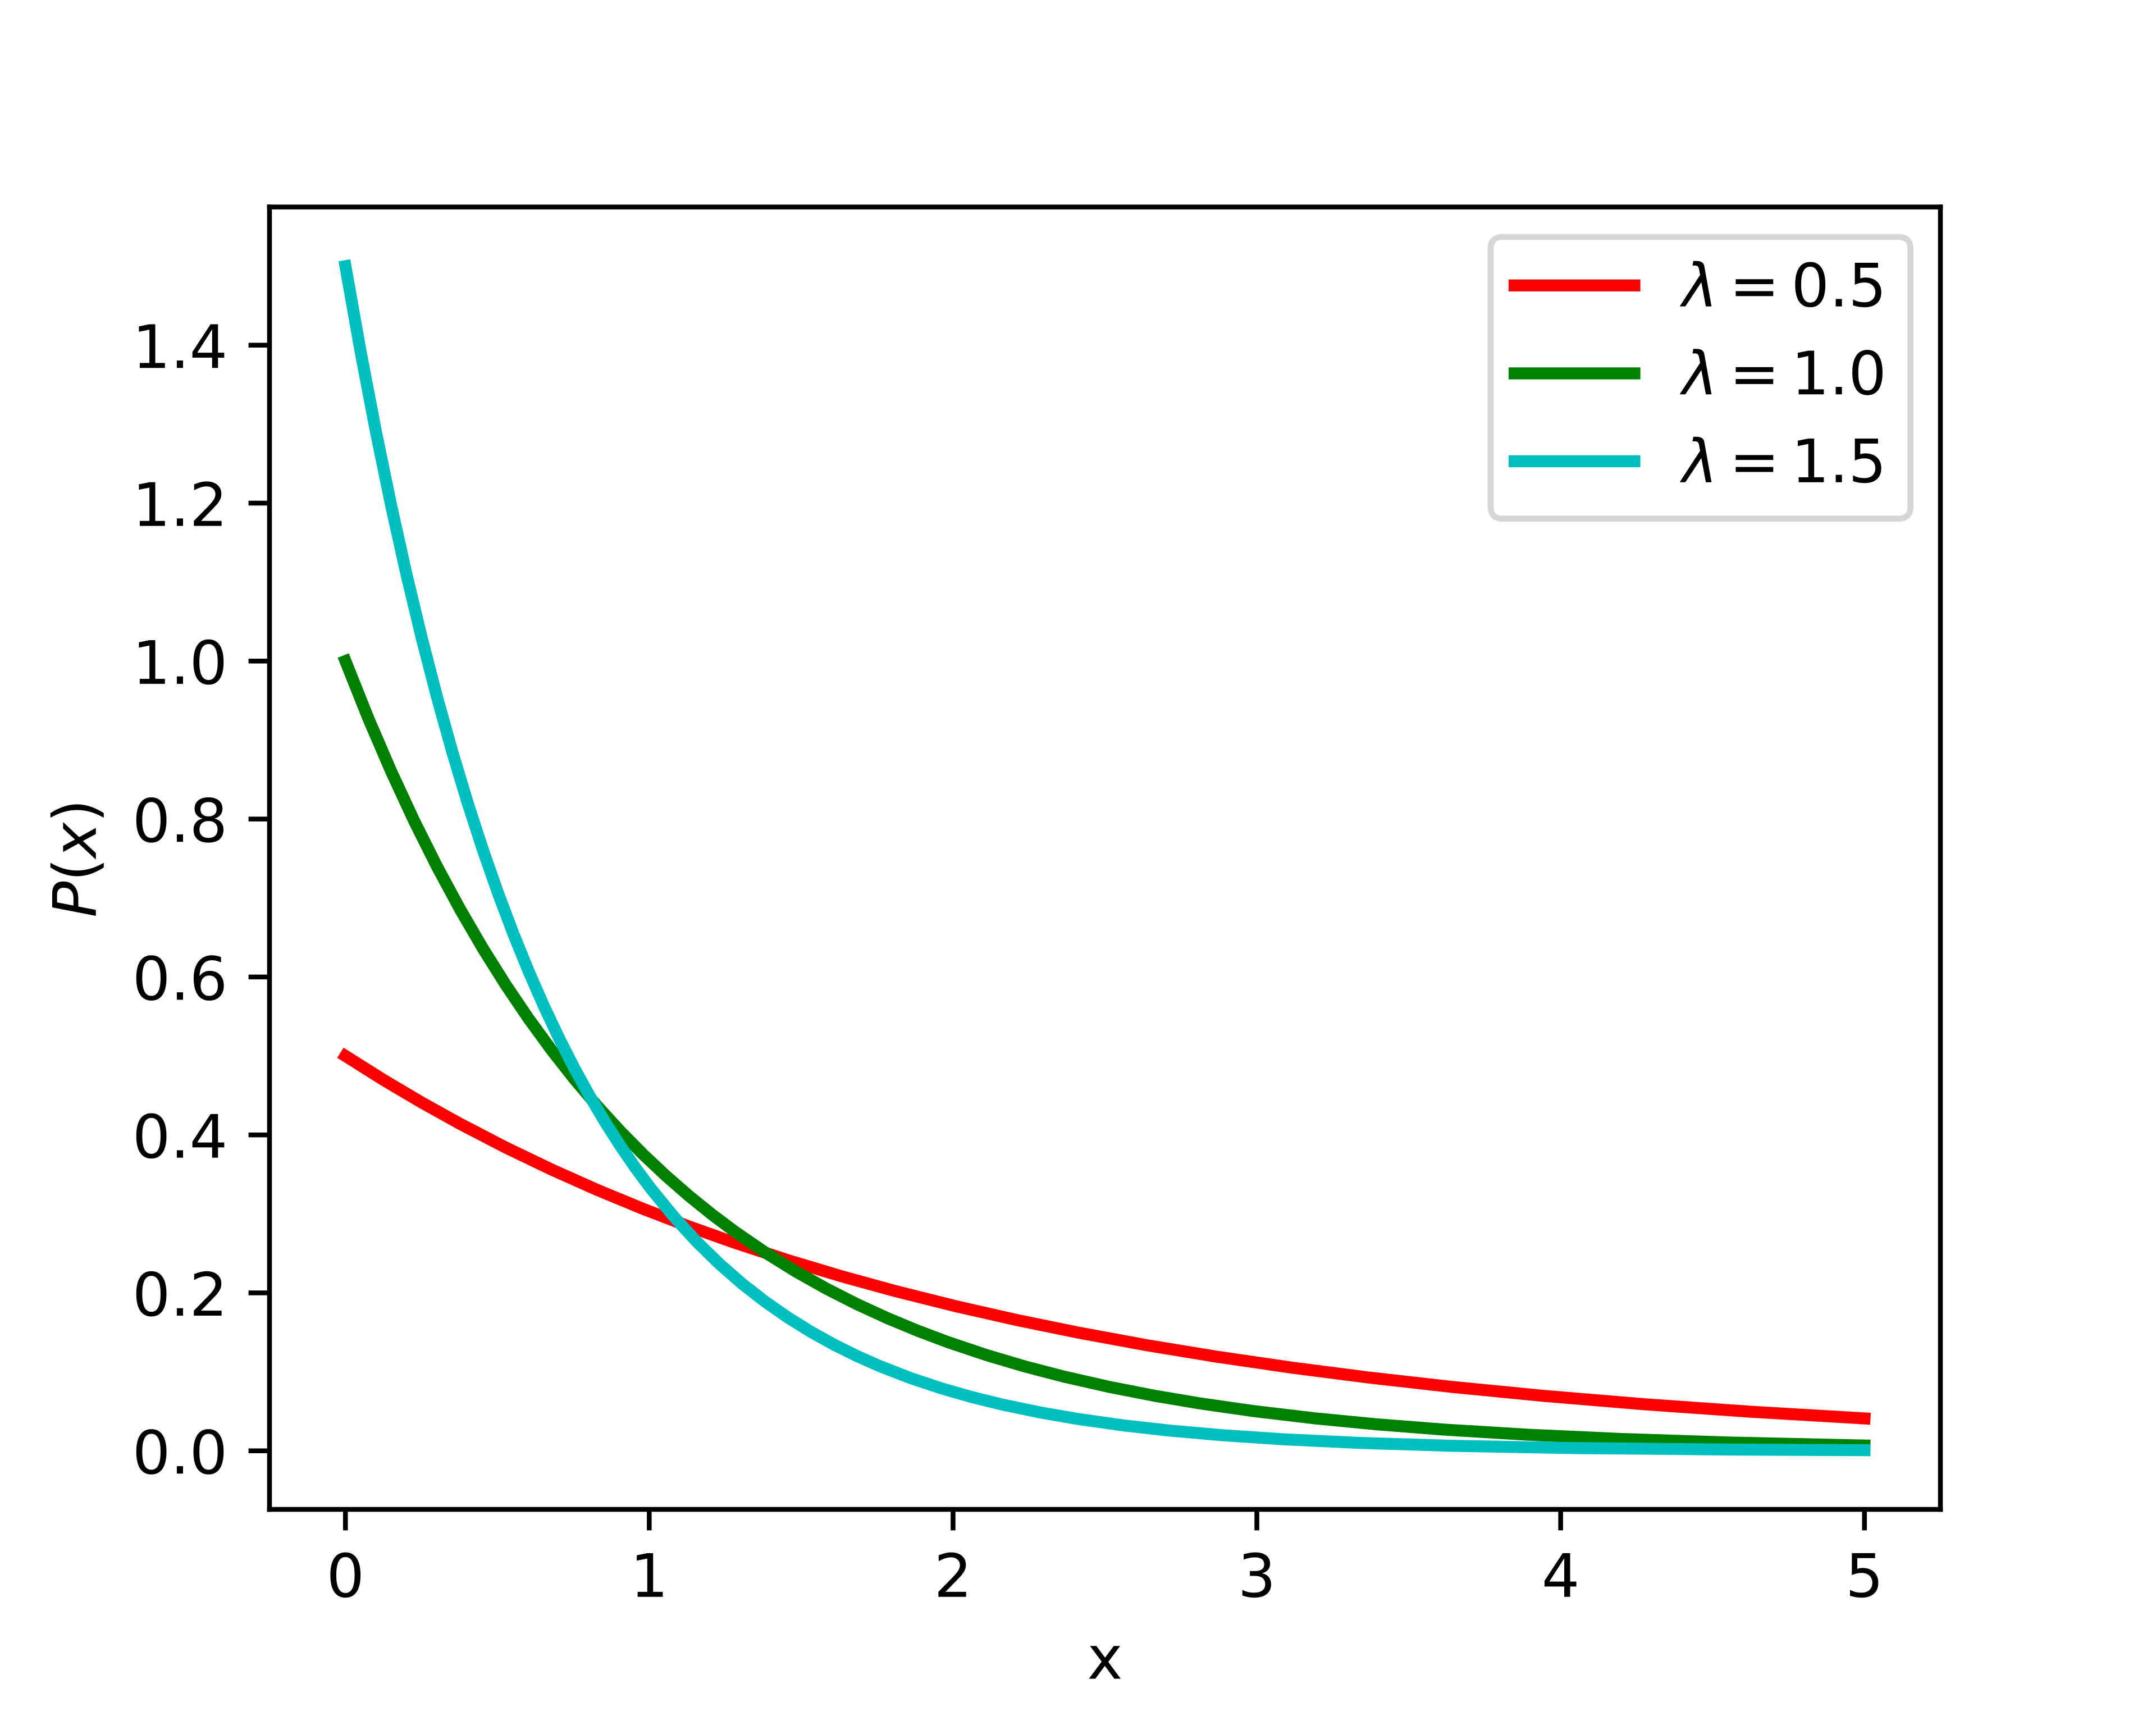

PDFs of Exponential distribution are shown above (https://en.wikipedia.org/wiki/Exponential_distribution#/media/File:Exponential_distribution_pdf_-_public_domain.svg)

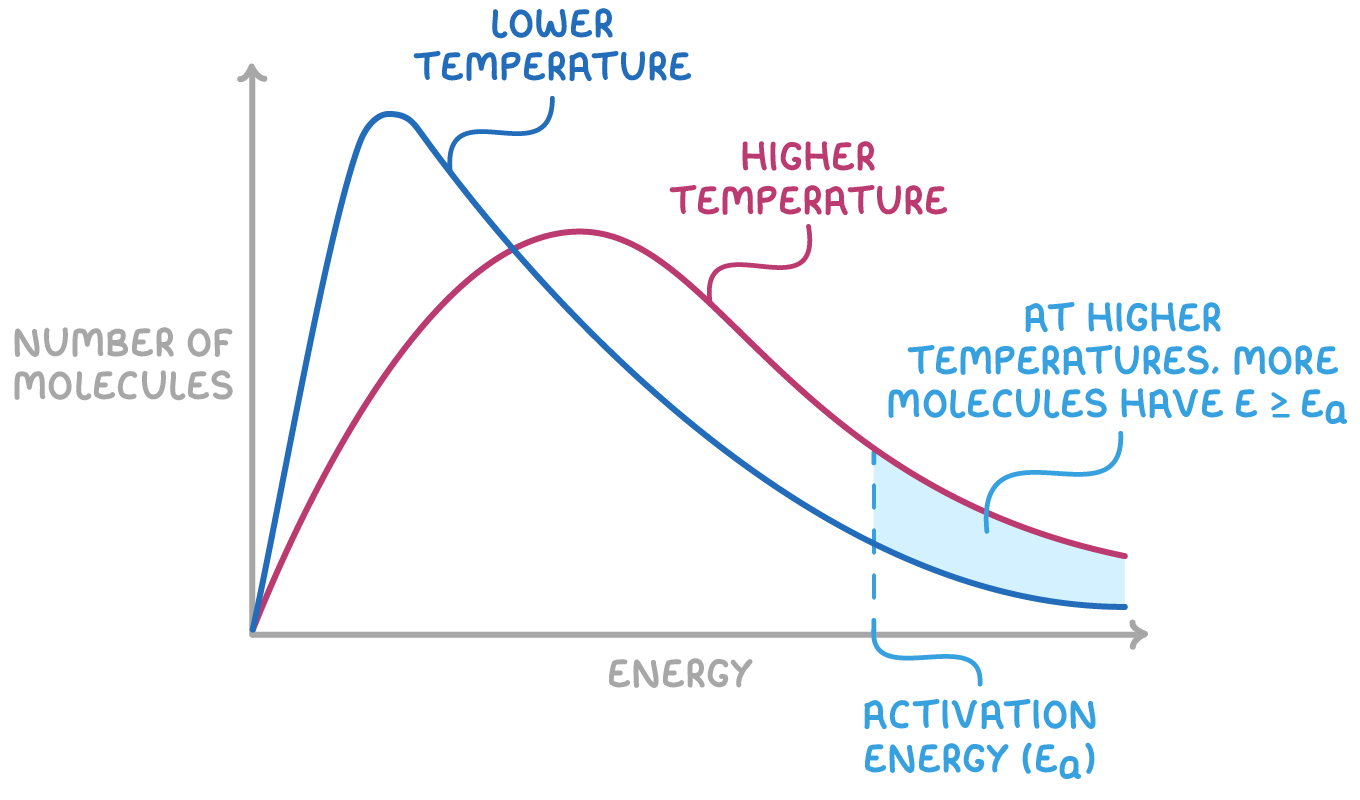

A visualization of how molecules are distributed across energy levels according to $P(ϵ)$  where $ϵ$ is the energy for one molecule

Source: https://puppeteer.cognitoedu.org/coursesubtopic/c3-alevel-aqa_JScZnKfp

# Question #2

In the above figure, the vertical axis is labeled as "number of molecules" because this figure was taken from an article discussing thermal physics.

How should we label the vertical axis if we want to use this figure to explain Boltzmann machine? In other words, we should change "number of molecules" to "number of ?"

number of network states or number of network configurations

### 4. The Concept of Thermal Equilibrium

The concept of thermal equilibrium in Boltzmann machine is the same as the thermal equilibrium in physics.

A neural network is considered to be at **thermal equilibrium** when it has reached a **stationary distribution** (Boltzmann distribution).

**Please note: a neural network is at thermal equilibrium does not mean it is at a fixed state. It only means that the distribution of its states is stationary.**

The **probability** of the neural network being in state $\mathbf{s}$ is given by the **Boltzmann distribution** at **thermal equilibrium**:

$$
P(\mathbf{s})
\;=\;
\frac{1}{Z}
\,e^{-\beta\, E(\mathbf{s})},
$$

where

$$
Z
\;=\;
\sum_{\mathbf{s}} e^{-\beta\,E(\mathbf{s})}
$$

is the **partition function**, summing over all possible states.







### 5. Learning Objective: Maximum Likelihood

To train a Boltzmann machine on a dataset $\{\mathbf{v}\}$, one typically tries to maximize the **log-likelihood** of the observed data or minimize the **negative log-likelihood**. Formally, we want:

$$
L
\;=\;
\log P(\{\mathbf{v}\}).
$$




### 6. Learning Rule (Maximizing the Log Likelihood of Data)

The learning rule is

$$
\Delta w_{ij} \propto \langle s_i s_j \rangle_{\text{data}} - \langle s_i s_j \rangle_{\text{model}}
$$

or

$$
\Delta w_{ij} = \eta (\langle s_i s_j \rangle_{\text{data}} - \langle s_i s_j \rangle_{\text{model}})
$$


where:

- $\eta$ is learning rate

- $\Delta w_{ij}$ is the connection weights between neurons $i$ and $j$

- $\langle \cdot \rangle_{\text{data}}$ is the **expectation** of $s_i s_j$ under the **data distribution** (with hidden units appropriately sampled)

- $\langle \cdot \rangle_{\text{model}}$ is the **expectation** under the **model's** distribution $P(\mathbf{s})$

# Question 3

If compared with backpropagation, do you think the learning rule of Boltzmann machine is more biologically plausible? Why?


Yes, compared with backpropagation, the BM learning rule is generally more biologically plausible because it relies more on local activity correlations between connected neurons, similar to Hebbian learning. Backpropagation depends on a global error signal being propagated backward through layers, which is harder to justify biologically.

#### **Derivation of the Learning Rule (Optional)**

A Boltzmann Machine defines the probability of a state $ \mathbf{s} $ using the **Boltzmann distribution** (assume $\beta = 1$):

$$
P(\mathbf{s}) = \frac{e^{-E(\mathbf{s})}}{Z}
$$

where:
- The **energy function** is:

  $$
  E(\mathbf{s}) = -\frac{1}{2} \sum_{i,j} w_{ij} s_i s_j - \sum_i \theta_i s_i.
  $$

- The **partition function** $ Z $ normalizes the probabilities:

  $$
  Z = \sum_{\mathbf{s}} e^{-E(\mathbf{s})}.
  $$

##### **Log-Likelihood Gradient**

To train a Boltzmann Machine, we **maximize the log-likelihood** of the observed data:

$$
L = \log P(\{\mathbf{v}\})
$$

Where

$$
P(\{\mathbf{v}\}) = \prod_\mathbf{all\;data\;v} \frac{e^{-E(\mathbf{v})}}{Z}
$$

and

$$
\log P(\{\mathbf{v}\}) = \sum_\mathbf{all\;data\;v} \log \left( \frac{e^{-E(\mathbf{v})}}{Z} \right) = \sum_\mathbf{v} \left( -E(\mathbf{v}) - \log Z \right)
$$

The gradient with respect to a weight $ w_{ij} $ is:

$$
\frac{\partial \log P(\{\mathbf{v}\})}{\partial w_{ij}} = \sum_\mathbf{v} \left( - \frac{\partial E(\mathbf{v})}{\partial w_{ij}} - \frac{1}{Z} \frac{\partial Z}{\partial w_{ij}} \right)
$$

Since:

$$
\frac{\partial Z}{\partial w_{ij}} = \sum_{\mathbf{all\;possible\;s}} -\frac{\partial E(\mathbf{s})}{\partial w_{ij}} e^{-E(\mathbf{s})},
$$

we get:

$$
\frac{\partial \log P(\{\mathbf{v}\})}{\partial w_{ij}} = \sum_{\mathbf{v}} \left( -\frac{\partial E(\mathbf{v})}{\partial w_{ij}} + \sum_{\mathbf{s}} \frac{\partial E(\mathbf{s})}{\partial w_{ij}} \frac{e^{-E(\mathbf{s})}}{Z} \right)
$$

$$
\frac{\partial \log P(\{\mathbf{v}\})}{\partial w_{ij}} = \sum_{\mathbf{v}} \left( -\frac{\partial E(\mathbf{v})}{\partial w_{ij}} + \sum_{\mathbf{s}} P_\text{model}(\mathbf{s})  \frac{\partial E(\mathbf{s})}{\partial w_{ij}} \right)
$$


##### **Compute the Energy Gradient**

From the energy function:

$$
E(\mathbf{s}) = - \frac{1}{2} \sum_{i,j} w_{ij} s_i s_j - \sum_i \theta_i s_i,
$$

we differentiate with respect to $ w_{ij} $:

$$
\frac{\partial E(\mathbf{s})}{\partial w_{ij}} = -s_i s_j
$$

Thus:

$$
\frac{\partial \log P(\{\mathbf{v}\})}{\partial w_{ij}} = \sum_{\mathbf{v}} s_i s_j - \sum_{\mathbf{v}} \sum_{\mathbf{s}} P_{\text{model}}(\mathbf{s}) s_i s_j = \sum_{\mathbf{v}} s_i s_j - \sum_{\mathbf{v}} \langle s_i s_j \rangle_{\text{model}} = N \langle s_i s_j \rangle_{\text{data}} - N \langle s_i s_j \rangle_{\text{model}}
$$

Where $N$ is the number of data points in the dataset $\{\mathbf{v}\}$

This gives the final learning rule by changing the weights in the direction that increases the log likelihood of data $\log P(\{\mathbf{v}\})$:

$$
\frac{\partial \log P(\{\mathbf{v}\})}{\partial w_{ij}} \propto \langle s_i s_j \rangle_{\text{data}} - \langle s_i s_j \rangle_{\text{model}}.
$$

$$
\Delta w_{ij} \propto \langle s_i s_j \rangle_{\text{data}} - \langle s_i s_j \rangle_{\text{model}}.
$$

or

$$
\Delta w_{ij} = \eta (\langle s_i s_j \rangle_{\text{data}} - \langle s_i s_j \rangle_{\text{model}})
$$

- $\eta$ is learning rate

- $ \langle s_i s_j \rangle_{\text{data}} $ is the expectation under the **data ensemble**.

- $ \langle s_i s_j \rangle_{\text{model}} $ is the expectation under the **model ensemble**.

- Learning adjusts the weights to **match the model's correlations with those found in real data**.

This rule is used in **Contrastive Divergence (CD)** for training **Boltzmann Machines (BMs)**.

The mean field approximation was used to approximate $\Delta w_{ij}$ when using sampling to approximate $\langle s_i s_j \rangle$ was too slow for the general fully connected Boltzmann machine:

$$
\Delta w_{ij}\approx \eta (
\langle s_i\rangle_{\text{data}}\langle s_j\rangle_{\text{data}}
-
\langle s_i\rangle_{\text{model}}\langle s_j\rangle_{\text{model}}
)
$$

However, the mean field approximation is no longer used for restricted Boltzmann machine.



### 7. Algorithm for Training a Boltzmann Machine

For **Boltzmann machines** (with hidden-to-hidden or visible-to-visible connections), training is usually very computationally expensive, requiring Markov Chain Monte Carlo (MCMC) methods (e.g. Gibbs Sampling) and approximate techniques (e.g., mean-field approximations).

During training, the network learns probability distributions over the data. The training process involves adjusting weights using the difference between expectations of neural activities computed from the **data distribution (ensemble)** and from the **model's distribution (ensemble)**.

#### **1. Initialize Parameters**
- Set initial weights $ W_{ij} $ and biases $ \theta_i $ randomly.
- Choose a learning rate $ \eta $.

#### **2. Perception (Positive Phase): Sampling from the Data Distribution and Compute the Expected Pairwise Correlations Under the Data Distribution**

- There are data inputs in this step.

- Given a dataset $ \{ \mathbf{v} \} $, **clamp the visible neurons** using the data in the dataset and their states cannot be changed after being clamped. **Only the hidden neurons are free to update their states.**

In other words, **the states of hidden neurons are not fixed**. There are many possible states for hidden neurons under this condition. However, **the probability distribution of the states for hidden neurons is stationary** (in thermal equilibrium).

For each neuron $i$, the probability of firing is:

  $$
  P(s_i = 1) = \sigma \left( \sum_j W_{ij} s_j + \theta_i \right)
  $$

  where $ \sigma(x) $ is the sigmoid function:

  $$
  \sigma(x) = \frac{1}{1 + e^{-x}}
  $$

Sample the states of hidden units and compute the expected pairwise correlations when different data points are used to clamp the visible neurons:

  $$
  \langle s_i s_j \rangle_{\text{data}} = \frac{1}{N} \sum_{\alpha=1}^{N} s_i^\alpha s_j^\alpha
  $$

  where $ N $ is the number of training samples and $s_i$, $s_j$ can be visible or hidden units (all pairs of all neurons).

#### **3. Reconstruction (Negative Phase): Sampling from the Model Distribution and Compute the Expected Pairwise Correlations Under the Model Distribution**

- There are no data inputs in this step.

- Generate samples $ \mathbf{s} $ from the model's probability distribution. **Both visible neurons and hidden neurons are free to update their states.**

In other words, **the states of both visible and hidden neurons are not fixed**. There are many possible states for visible and hidden neurons under this condition. However, **the probability distribution of the states for visible and hidden neurons is stationary** (in thermal equilibrium).

For each neuron $i$, the probability of firing is:

  $$
  P(s_i = 1) = \sigma \left( \sum_j W_{ij} s_j + \theta_i \right)
  $$

  where $ \sigma(x) $ is the sigmoid function:

  $$
  \sigma(x) = \frac{1}{1 + e^{-x}}
  $$

- After sampling from the model, compute the expectation under the model's distribution:

  $$
  \langle s_i s_j \rangle_{\text{model}} = \frac{1}{K} \sum_{\beta=1}^{K} s_i^\beta s_j^\beta
  $$

  where $ K $ is the number of samples generated.

#### **4. Learning: Update Weights Using Contrastive Divergence**
- Adjust the weights using gradient descent:

  $$
  \Delta W_{ij} = \eta \left( \langle s_i s_j \rangle_{\text{data}} - \langle s_i s_j \rangle_{\text{model}} \right)
  $$

- Update biases:

  $$
  \Delta \theta_i = \eta \left( \langle s_i \rangle_{\text{data}} - \langle s_i \rangle_{\text{model}} \right)
  $$

#### **5. Repeat Until Convergence**
- Iterate steps **2-4** until the weight updates become small or a maximum number of epochs is reached.

#### **Summary**

- **Data ensemble statistics** are computed from training data samples by clamping visible units to the data and measuring correlations or expectations $\langle s_i s_j \rangle$ under $P(h|v)$ (data ensemble)

- **Model ensemble statistics** are estimated using **Gibbs sampling** from the neural network's free-running distribution $P_{\text{model}}(s)$ (model ensemble)

- **Weights and biases** are updated based on the difference between **data ensemble statistics** and **model ensemble statistics**.

This training procedure allows the Boltzmann Machine to learn a probability distribution over the input data.



#### **Gibbs Sampling: A Markov Chain Monte Carlo (MCMC) Method**

Gibbs Sampling is a stochastic algorithm used to generate samples from a **joint probability distribution** when direct sampling is difficult. It is widely used in **Boltzmann Machines, Bayesian inference, and statistical physics**.

Instead of sampling the full **joint distribution** $ P(x_1, x_2, ..., x_n) $ directly, Gibbs Sampling samples **one variable at a time** from its **conditional distribution**:

$$
x_i^{(t+1)} \sim P(x_i \mid x_1^{(t+1)}, ..., x_{i-1}^{(t+1)}, x_{i+1}^{(t)}, ..., x_n^{(t)})
$$

- The updated variable **depends on the latest values of all other variables**.

- Repeating this process **eventually produces samples from the true joint distribution**.

**Reason**: It is useful when sampling directly from $ P(x_1, x_2, ..., x_n) $ is hard, but sampling from each **conditional probability** $ P(x_i \mid \text{rest}) $ is easy.

---

##### **Algorithm Steps**

1. **Initialize** all variables with random values.

2. **Iterate through each variable $ x_i $ and update it using its conditional probability**:

   - Sample $ x_1^{(t+1)} \sim P(x_1 \mid x_2^{(t)}, x_3^{(t)}, ..., x_n^{(t)}) $

   - Sample $ x_2^{(t+1)} \sim P(x_2 \mid x_1^{(t+1)}, x_3^{(t)}, ..., x_n^{(t)}) $

   - Continue for all variables.

3. **Repeat for multiple iterations** until the samples converge to the true distribution.

---

##### **Gibbs Sampling Procedure for General Boltzmann Machines**

1. **Initialize** all neurons $ s_i $ randomly.

2. **For each neuron $ s_i $, update it based on the states of all other neurons**:

   $$
   P(s_i = 1 \mid \mathbf{s}_{\setminus i}) = \sigma \left( \sum_j W_{ij} s_j + \theta_i \right)
   $$

   where $\mathbf{s}_{\setminus i}$ contains all neurons' states except $s_i$ and $ \sigma(x) $ is the **sigmoid function**:

   $$
   \sigma(x) = \frac{1}{1 + e^{-x}}
   $$

3. **Repeat for all neurons $ s_i $, updating one at a time in a random order**.

4. **Perform multiple iterations** until the system reaches thermal equilibrium (distribution of samples becomes stationary).

5. **Extract samples** from the equilibrium distribution.


Because the Gibbs sampling procedure is very computationally expensive, training a **general Boltzmann machine** is usually **very difficult**.

Therefore, the **Restricted Boltzmann Machines (RBMs)** was invented to improve performance and make the training easier.

The Restricted Boltzmann Machines is a special case of Boltzmann machine with bipartite connections only.

**An RBM consists of only two layers:**

- Visible Layer → Represents input data.

- Hidden Layer → Extracts features from the input.

**Restricted Connectivity:**

- There are no connections between visible units.

- There are no connections between hidden units.

- Every visible unit is connected to every hidden unit.

RBMs can be trained using the algorithm described above with the new Gibbs sampling procudure below, so the training is much easier than the general Boltzmann machine.


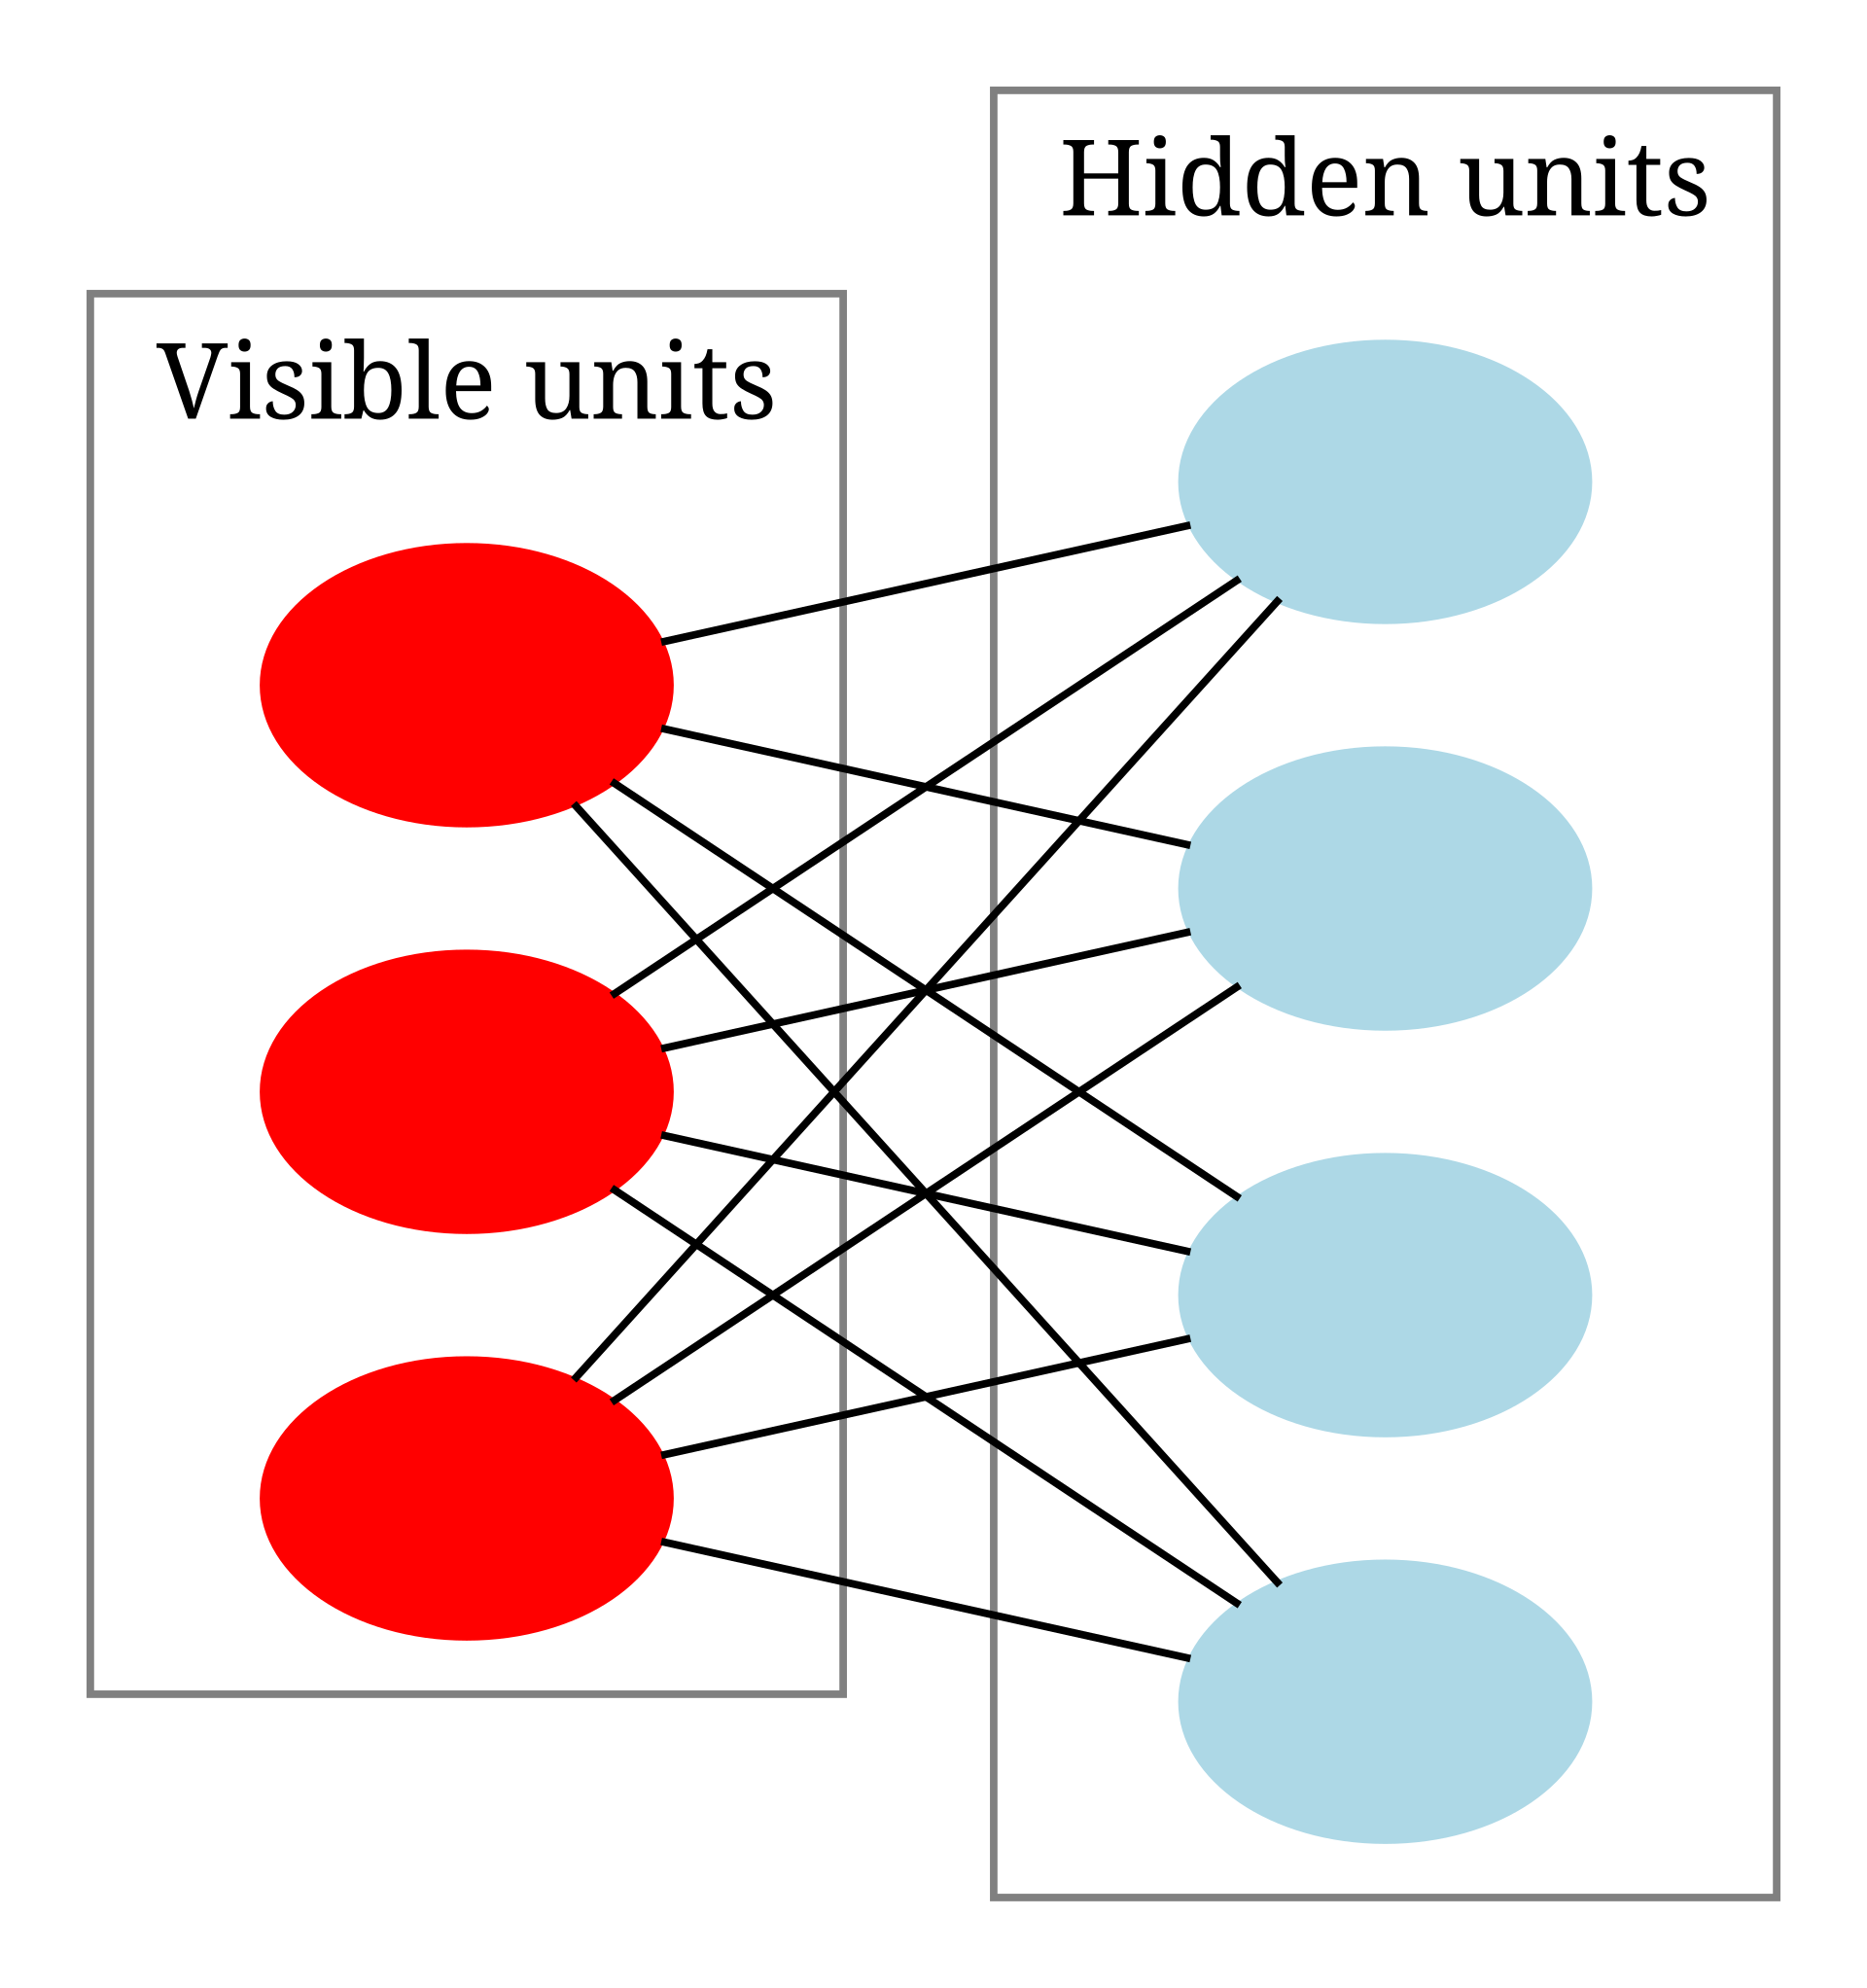

Source: https://en.wikipedia.org/wiki/Boltzmann_machine#/media/File:Restricted_Boltzmann_machine.svg

##### **Gibbs Sampling in Restricted Boltzmann Machines**

In **Restricted Boltzmann Machines**, Gibbs Sampling is used to update **visible and hidden neurons iteratively**.

1. **Initialize** all variables with random values.

2. **Update Hidden Units**:
   $$
   P(h_j = 1 \mid \mathbf{v}) = \sigma \left( \sum_i W_{ij} v_i + b_j \right)
   $$
3. **Update Visible Units**:
   $$
   P(v_i = 1 \mid \mathbf{h}) = \sigma \left( \sum_j W_{ij} h_j + b_i \right)
   $$
4. **Repeat steps 2 and 3 many times** until the system reaches thermal equilibrium (distribution of samples becomes stationary).

**This allows the model to learn the probability distribution of the data and model ensembles.**

## Implement a Restricted Boltzmann Machine

Write a class for a restricted Boltzmann Machine that can perceive and infer image data

# Coding Exercise #1 #2 #3  

In [2]:

class RBM(nn.Module):
    def __init__(self, visible_size, hidden_size):
        super().__init__()
        self.visible_size = visible_size
        self.hidden_size = hidden_size

        # We store W, v_bias, h_bias as Parameters so they're easy to move to GPU if needed,
        # but we'll update them manually based on Boltzmann machine's learning rule (not via standard PyTorch autodiff).

        self.W = nn.Parameter(torch.randn(hidden_size, visible_size)*0.01)
        self.v_bias = nn.Parameter(torch.zeros(visible_size))
        self.h_bias = nn.Parameter(torch.zeros(hidden_size))

    def sample_from_p(self, p):
        """
        Given probabilities p in [0,1], sample Bernoulli {0,1}.
        """
        return torch.bernoulli(p)


#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #1")
#############################################################################

    def v_to_h(self, v):
        """
        p(h|v) = sigmoid(v @ W^T + b).
        v shape: (batch_size, visible_size)
        returns (p_h, h_sample) of shape (batch_size, hidden_size).
        """
        # W is [hidden_size, visible_size], so W @ v^T => hidden x batch => we need to transpose
        # so we do v @ W^T here

        p_h = torch.sigmoid(torch.matmul(v, self.W.t()) + self.h_bias)  # hint: self.W.t() for transpose, output shape: (batch_size, hidden_size)
        h_sample = self.sample_from_p(p_h)

        return p_h, h_sample

    def h_to_v(self, h):
        """
        p(v|h) = sigmoid(W^T @ h + a).
        h shape: (batch_size, hidden_size)
        returns (p_v, v_sample) of shape (batch_size, visible_size).
        """
        p_v = torch.sigmoid(torch.matmul(h, self.W) + self.v_bias)
        v_sample = self.sample_from_p(p_v)

        return p_v, v_sample

    def contrastive_divergence(self, v0, k=1, lr=0.01):
        """
        Perform one parameter update via Contrastive Divergence with k-step Gibbs Sampling (CD-k).
        v0: initial visible batch (shape: [batch_size, visible_size]).
        k: number of Gibbs steps
        lr: learning rate
        """
        batch_size = v0.size(0)

        # Positive phase
        # -----------------------------------------------------
        #  Compute h0 from v0
        p_h0, h0 = self.v_to_h(v0)


#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #2")
#############################################################################

        # Start the negative phase
        vk = v0.clone()
        hk = h0.clone()

        # k-step Gibbs sampling
        # -----------------------------------------------------
        for _ in range(k):
            p_vk, vk_sample = self.h_to_v(hk) # Sample visible units when hidden units are fixed as hk
            p_hk, hk_sample = self.v_to_h(vk_sample) # Sample hidden units when visible units are fixed as vk_sample
            vk = vk_sample
            hk = hk_sample

        # After k steps, we have (vk, hk)
        # the number of negative phase samples is equal to batch_size
        # -----------------------------------------------------
        v1 = vk
        h1 = hk

        # 1) Positive correlation: <v0^T h0>

        # We'll want to transpose to match W's shape [h, v].
        # do h0^T v0:
        # shape(h0) = [b, h], shape(v0) = [b, v]
        # h0^T => [h, b], v0 => [b, v]
        # => h0^T @ v0 => [h, v] => that matches W's shape

        pos_corr = torch.matmul(h0.t(), v0)  # shape (h, v)

        # 2) Negative correlation: <v1^T h1>
        #    Same logic: shape => [h, v]
        neg_corr = torch.matmul(h1.t(), v1)

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #3")
#############################################################################

        # 3) Update W
        # we do torch.no_grad() since we do manual updates
        with torch.no_grad():
            self.W += lr * (pos_corr - neg_corr) / batch_size

            # 4) Update biases
            #    v_bias += lr * (v0 - v1).mean(dim=0)
            #    h_bias += lr * (h0 - h1).mean(dim=0)
            self.v_bias += lr * torch.mean(v0 - v1, dim=0)
            self.h_bias += lr * torch.mean(h0 - h1, dim=0)

        # Return the reconstruction error or some metric if we want to track progress
        # For instance, MSE or negative log-likelihood approx
        recon_error = torch.mean((v0 - v1)**2)
        return recon_error


Train a restricted Boltzmann Machine to infer (reconstruct) input image data (perception)

In [3]:

# ---------------------------------------------------------------------
# 1) HYPERPARAMETERS
# ---------------------------------------------------------------------

batch_size = 64
visible_size = 28*28  # input MNIST images are 28x28
hidden_size = 128     # number of hidden units
num_epochs = 20        # training epochs
k_step = 1            # CD-k: here we do k=1
lr = 0.01             # learning rate

# ---------------------------------------------------------------------
# 2) LOAD MNIST DATA
# ---------------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),    # convert [0,255] -> [0,1]
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])

train_dataset = datasets.MNIST(root="./data", train=True,
                               transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


# ---------------------------------------------------------------------------
# Training loop
# ---------------------------------------------------------------------------

def train_rbm(rbm, train_loader, lr=0.01, k=1, num_epochs=5):
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for batch_idx, (data, _) in enumerate(train_loader):

            # data is [batch_size, 784] in [0,1].
            data = (data>0.5).float() # binarize the data

            # One Contrastive Divergence with k model samples (CD-k) update
            loss = rbm.contrastive_divergence(data, k=k, lr=lr)
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Avg Reconstruction Loss: {avg_loss:.4f}")

    return rbm

# 3) Init RBM
rbm = RBM(visible_size, hidden_size)

# 4) Train
rbm = train_rbm(rbm, train_loader, lr=lr, k=k_step, num_epochs = 20)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.84MB/s]


Epoch [1/20], Avg Reconstruction Loss: 0.1692
Epoch [2/20], Avg Reconstruction Loss: 0.1197
Epoch [3/20], Avg Reconstruction Loss: 0.1065
Epoch [4/20], Avg Reconstruction Loss: 0.0986
Epoch [5/20], Avg Reconstruction Loss: 0.0931
Epoch [6/20], Avg Reconstruction Loss: 0.0888
Epoch [7/20], Avg Reconstruction Loss: 0.0853
Epoch [8/20], Avg Reconstruction Loss: 0.0827
Epoch [9/20], Avg Reconstruction Loss: 0.0803
Epoch [10/20], Avg Reconstruction Loss: 0.0783
Epoch [11/20], Avg Reconstruction Loss: 0.0765
Epoch [12/20], Avg Reconstruction Loss: 0.0750
Epoch [13/20], Avg Reconstruction Loss: 0.0736
Epoch [14/20], Avg Reconstruction Loss: 0.0724
Epoch [15/20], Avg Reconstruction Loss: 0.0713
Epoch [16/20], Avg Reconstruction Loss: 0.0703
Epoch [17/20], Avg Reconstruction Loss: 0.0694
Epoch [18/20], Avg Reconstruction Loss: 0.0685
Epoch [19/20], Avg Reconstruction Loss: 0.0678
Epoch [20/20], Avg Reconstruction Loss: 0.0670


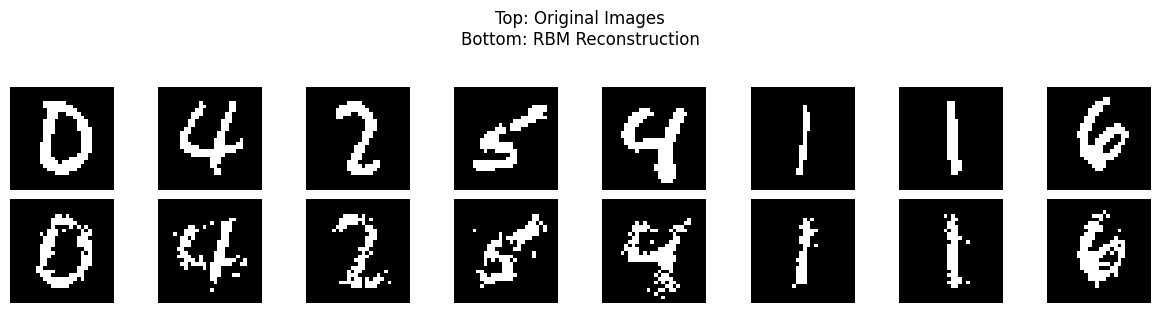

In [4]:

def reconstruct_images(rbm, data, n_images=8, binarize=True):
    """
    Reconstruct 'n_images' samples from 'data' using the trained RBM.
    :param rbm: your trained RBM instance
    :param data: a batch of input images, shape [batch_size, 784]
    :param n_images: how many images to reconstruct and display
    :param binarize: if True, threshold input data at 0.5 for Bernoulli units
    """
    # binarize the input data
    if binarize:
        data = (data > 0.5).float()

    # Pick the first n_images from 'data'
    v_orig = data[:n_images]

    # Forward pass: v -> h
    with torch.no_grad():
        p_h, h_sample = rbm.v_to_h(v_orig)
        # Reconstruct: h -> v
        p_v, v_recon_sample = rbm.h_to_v(h_sample)

    # Convert tensors to numpy
    v_orig_np = v_orig.cpu().numpy()
    v_recon_np = v_recon_sample.cpu().numpy()

    # Plot side by side
    fig, axes = plt.subplots(2, n_images, figsize=(1.5*n_images, 3))
    for i in range(n_images):
        # Original
        ax_orig = axes[0, i] if n_images > 1 else axes[0]
        ax_orig.imshow(v_orig_np[i].reshape(28, 28), cmap='gray')
        ax_orig.axis('off')

        # Reconstructed
        ax_rec = axes[1, i] if n_images > 1 else axes[1]
        ax_rec.imshow(v_recon_np[i].reshape(28, 28), cmap='gray')
        ax_rec.axis('off')

    plt.suptitle("Top: Original Images\nBottom: RBM Reconstruction", y=1.03)
    plt.tight_layout()
    plt.show()


# Get a batch of MNIST images from your train_loader
data_iter = iter(train_loader)
images, _ = next(data_iter)  # images shape: [batch_size, 784], [batch_size]

# Reconstruct them
reconstruct_images(rbm, images, n_images=8, binarize=True)

## **Boltzmann Machines and Perception as Inference**

### **Perception as Inference: Theoretical Background**

**Key Idea: The Brain as a Probabilistic Inference Machine**

- The **brain does not directly "see" reality** but rather **infers the most likely causes** of sensory inputs.
- **Bayesian inference** plays a crucial role in how the brain integrates noisy sensory data.
- Neural activity can be seen as computing **probabilistic expectations** about the environment.

####**Probabilistic Formulation**
Perception can be framed as **inferring hidden causes** $ h $ given sensory input $ v $:

$$
P(h \mid v) = \frac{P(v \mid h) P(h)}{P(v)}
$$

where:
- $ P(h) $ is the **prior belief** about hidden causes.
- $ P(v \mid h) $ is the **likelihood function**, modeling how causes generate observations.
- $ P(h \mid v) $ represents **perception as inference**.

**This is mathematically similar to how Boltzmann Machines infer hidden states given visible data.**

---

### **How Boltzmann Machines Perform Inference**

A **Boltzmann Machine** learns a **joint probability distribution** over visible and hidden variables:

$$
P(v, h) = \frac{e^{-E(v, h)}}{Z}
$$

where:
- $ v $ represents **observed sensory data**.
- $ h $ represents **hidden causes (higher-level features)**.
- $ E(v, h) $ is the **energy function**, defining interactions between neurons.

#### **Inference in Boltzmann Machines**
Given an observed input $ v $, the BM infers the most probable hidden states $ h $:

$$
P(h_j = 1 \mid v) = \sigma \left( \sum_i W_{ij} v_i + b_j \right)
$$

where $ \sigma(x) = \frac{1}{1 + e^{-x}} $ is the **sigmoid function**.

**This resembles how the brain infers hidden causes from sensory input.**

---

#### **Similarities Between Perception and Boltzmann Machines**
| **Feature** | **Perception as Inference** | **Boltzmann Machine** |
|------------|----------------------|---------------------|
| **Sensory Inputs** | Raw sensory data (vision, sound) | Visible units $ v $ |
| **Hidden Causes** | Internal representations (objects, patterns) | Hidden units $ h $ |
| **Inference Mechanism** | Bayesian update of beliefs | Gibbs sampling or MCMC |

**Perception in the brain can be seen as a probabilistic inference process, much like a Boltzmann Machine.**

---

### **Biological and Neuroscientific Perspectives**

#### **Predictive Coding and the Boltzmann Machine**

- **Predictive coding** suggests that the brain constantly generates predictions and updates beliefs based on **prediction errors**.

- This is similar to **Contrastive Divergence (CD)** in Boltzmann Machines, where the model refines its weights by minimizing differences between **expected** and **observed** states.

#### **Hierarchical Representation in the Brain**

- The brain organizes information **hierarchically** (low-level features → high-level objects).

- **Deep Boltzmann Machines (DBMs)** and **Deep Belief Networks (DBNs)** capture similar **hierarchical structures** in learning representations.

**This suggests that Boltzmann Machines provide a computational model of perception as inference.**




**Hopfield $\to$ Boltzmann**:
  - A Hopfield network is essentially a **deterministic** energy-based network for storing patterns in all visible neurons.  
  - Boltzmann machines incorporate **stochastic** neuron updates, **visible and hidden neurons**, and a **maximum-likelihood** perspective to learn complex distributions over data.  
  - The Boltzmann distribution $P(\mathbf{x}) = e^{-\beta E(\mathbf{x})}/Z$ determines the network's equilibrium state.  
  - Learning in Boltzmann machine seeks to match **model correlations** to **data correlations** using approximate methods like **Contrastive Divergence**.  
  - Boltzmann machines unify ideas from **statistical mechanics** and **neural computation** (energy-based learning, attractor dynamics) into a **generative model framework**.

## Summary of Boltzmann Machines

1. **Stochastic Units**  
   Each neuron is treated like a spin in statistical mechanics, flipping with a probability governed by the local field. This **temperature-dependent** flipping makes the network explore a distribution of states rather than just settle into a single minimum.

2. **Powerful Generative Model**  

   Because it learns a **joint distribution over data $P(\mathbf{v})$**, a trained Boltzmann machine can generate artificial data by running its stochastic dynamics from a random initial state.

3. **Hidden Units**  

   They allow the network to capture complex, high-order dependencies among visible units. This is a key difference from the basic Hopfield net, which only has visible units.

4. **Relation to Hopfield**  

   - **Hopfield Network**: A **special case** of a Boltzmann machine with no hidden units, usually run deterministically (though it can be extended to a low-temperature limit).  

   - **Boltzmann Machine**: A **generalization** that includes hidden units, fully stochastic dynamics, and a direct link to maximum likelihood learning in statistical physics.

5. **Training Complexity**  

   Boltzmann machines can be computationally difficult to train because computing exact gradients requires expensive sampling from the data ensemble and the model ensemble.
   
   Therefore, practical variants like **Restricted Boltzmann Machines (RBMs)** are developed later to improve performance.